### This jupyter notebook contains contents of the lesson "Random Forests"

**Author : Umidjon Sattorov. Machine Learning engineer**

___

**Decision Tree models in Regression tasks**

In [1]:
# Importing necessary libraries
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# Loading dataframe
data = {
    'Height' : [150, 155, 160, 170, 175, 180],
    'Gender' : [1, 1, 1, 0, 0, 0],
    'Weight' : [52, 54, 56, 65, 68, 72]
}
df = pd.DataFrame(data)
df

,Height,Gender,Weight
0,150,1,52
1,155,1,54
2,160,1,56
3,170,0,65
4,175,0,68
5,180,0,72


In [3]:
# Splitting data and making ML model
x_data = df.drop(columns = 'Weight')
y = df['Weight']

dc = DecisionTreeRegressor(random_state = 42)
dc.fit(x_data, y)
pred_y = dc.predict(x_data)

# Checking Metrics
print(f"Mean Squared Error of the model : {mean_squared_error(y, pred_y)}")

Mean Squared Error of the model : 0.0


In [6]:
dc.predict(df[['Height', 'Gender']])

array([52., 54., 56., 65., 68., 72.])

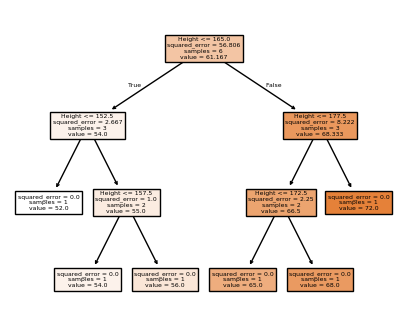

In [7]:
# Visualization of Tree model
from sklearn import tree

cols = df.drop(columns = 'Weight').columns
classes = df['Weight'].unique().astype(str)

plt.figure(figsize = (5, 4))
tree.plot_tree(dc, feature_names = cols, class_names = classes, filled = True)
plt.show()

___

### In this practical work we are gonna work with california housing dataset. Goal of this practical work is making AI model to predict the prices of the houses based on other features


In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing(as_frame = True)

X = data.data
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
# Checking if there is any NAN values in the dataset
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [8]:
# Splitting data into training and test datasets
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [9]:
# Using Decision Tree model for price prediction model
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor()

model_dt.fit(Xtrain, ytrain)

pred_dt = model_dt.predict(Xtest)

mean_squared_error(ytest, pred_dt)

0.5262904077949805

In [10]:
# Random Forest Regressor model performance
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor()

model_rf.fit(Xtrain, ytrain)

pred_rf = model_rf.predict(Xtest)

mean_squared_error(ytest, pred_rf)

0.25814880111572064

____

## Hyperparameters in Random Forest Regressor

* n_estimators — number of trees in the forest.

* criterion — the function used to measure the quality of a split (e.g., “mse”, “friedman_mse”, “mae”, etc.).

* max_depth — the maximum depth of each tree in the forest.

* min_samples_split — the minimum number of samples required to split an internal node.

* min_samples_leaf — the minimum number of samples required to be at a leaf node (a terminal node).

* max_features — the maximum number of features to consider when looking for the best split at each node.

* max_samples — the maximum number of samples to draw from the original dataset (using bootstrap) to train each individual tree.

Text(0, 0.5, 'MSE on test')

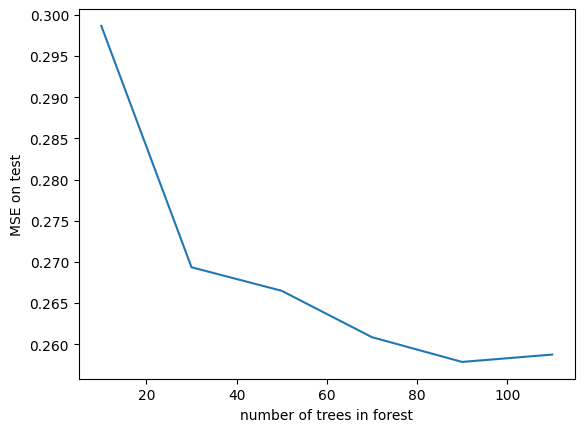

In [ ]:
# Let's change the number of estimators to see how it effects the quality of the model
N = []
MSE = []

for n in np.arange(10, 120, 20):
    rf = RandomForestRegressor(n_estimators = n)

    rf.fit(Xtrain, ytrain)
 
    pred_rf = rf.predict(Xtest)

    N.append(n)
    MSE.append(mean_squared_error(ytest, pred_rf))

plt.plot(N, MSE, '-')
plt.xlabel('number of trees in forest')
plt.ylabel('MSE on test')

OK, from the graph, it seems like 90 is the best choice in our case, so why we don't have to use 90 and then change other hyperparameters.

Text(0, 0.5, 'MSE on test')

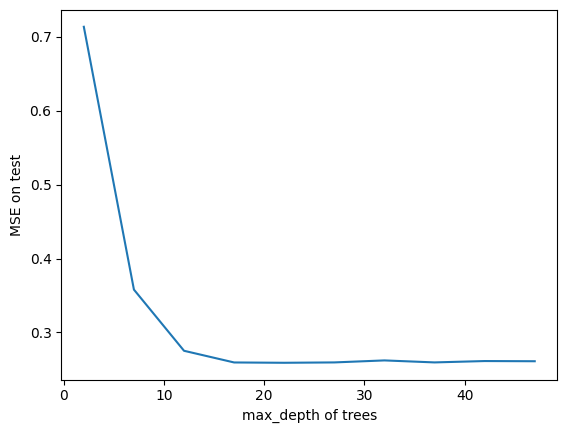

In [11]:
# Changint the hyperparameters D(Maximum Depth of the Decision trees)
D = []
MSE = []

for d in np.arange(2, 50, 5):
    rf = RandomForestRegressor(n_estimators = 90, max_depth = d)

    rf.fit(Xtrain, ytrain)

    pred_rf = rf.predict(Xtest)

    D.append(d)
    MSE.append(mean_squared_error(ytest, pred_rf))

# Visualization quality change when max depth changes
plt.plot(D, MSE, '-')
plt.xlabel('max_depth of trees')
plt.ylabel('MSE on test')

In [12]:
# Checking final performance of the model with best parameters
model_rf = RandomForestRegressor(n_estimators = 90, max_depth = 20)

model_rf.fit(Xtrain, ytrain)

pred_rf = model_rf.predict(Xtest)

mean_squared_error(ytest, pred_rf)

0.2626213152582877

It seems like we decreased the quality of the mdoel with some hyperparameters, let's see if we have actually decreased the quality with cross validation.

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(RandomForestRegressor(n_estimators = 90, max_depth = 15), X, y, cv = 3, scoring = 'neg_mean_squared_error')
scores

array([-0.50878102, -0.33155736, -0.53568677])

In [21]:
np.mean(-scores)

np.float64(0.4586750494849732)

In [22]:
np.std(-scores)

np.float64(0.09055444288482459)

In [16]:
# Checking first model in cross validation
scores = cross_val_score(RandomForestRegressor(), X, y, cv = 3, scoring = 'neg_mean_squared_error')
print(f"Average quality of the Random Forest : {np.mean(-scores)}")
print(f"Standart Deviation of the Random Forest : {np.std(-scores)}")

Average quality of the Random Forest : 0.4540329945625981
Standart Deviation of the Random Forest : 0.08879343582284567


____

**Grid Search**

In [ ]:
# Implemenation of Grid Search
from sklearn.model_selection import GridSearchCV

params = {'max_depth' : np.arange(2, 25, 4),
          'max_features' : ['sqrt', 'log2', None],
          'n_estimators': np.arange(70, 120, 5)}

gs = GridSearchCV(RandomForestRegressor(), params, cv = 3, scoring = 'neg_mean_squared_error')

gs.fit(Xtrain, ytrain)

In [24]:
gs.best_estimator_

,n_estimators,90
,criterion,'squared_error'
,max_depth,np.int64(18)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
gs.best_score_

np.float64(-0.25254617244888095)

In [26]:
model = gs.best_estimator_

model.fit(Xtrain, ytrain)

,n_estimators,90
,criterion,'squared_error'
,max_depth,np.int64(18)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
pred = model.predict(Xtest)

mean_squared_error(ytest, pred)

0.24273994138123736